<a href="https://colab.research.google.com/github/Edy567/Resnet18-Pneumonia-Model/blob/main/PneumoniaModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import torch
import kagglehub
import numpy as np
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch.nn.functional as F

from collections import Counter
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
sns.set_style('whitegrid')

In [3]:
#Setting up the data
train_transforms = transforms.Compose([transforms.Resize((224,224)) , transforms.RandomHorizontalFlip(), transforms.RandomRotation(15),
                                      transforms.ColorJitter(brightness=0.2, contrast=0.2), transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) ])

In [4]:
test_val_transforms = transforms.Compose([transforms.Resize((224,224)) , transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

In [5]:

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [6]:
train_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"
test_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/test"
val_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/val"

train_data = ImageFolder(train_dir, transform=train_transforms)
test_data = ImageFolder(test_dir, transform=test_val_transforms)
val_data = ImageFolder(val_dir, transform=test_val_transforms)

In [7]:
labels = [train_data[i][1] for i in range(len(train_data))]
len(labels)

5216

In [8]:
labels_count = Counter(labels)
df = pd.DataFrame({
    'Class': ['NORMAL', 'PNEUMONIA'],
    'Count': [labels_count[0], labels_count[1]]
})

df

,Class,Count
0,NORMAL,1341
1,PNEUMONIA,3875


In [9]:
train_loader = DataLoader(dataset = train_data, batch_size = 32,shuffle = True, num_workers = 4, pin_memory = True)
test_loader = DataLoader(dataset = test_data, batch_size = 32, shuffle = False, num_workers = 4, pin_memory = True)
val_loader =  DataLoader(dataset = val_data, batch_size = 32, shuffle = False, num_workers = 4, pin_memory = True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


(0.0, 4500.0)

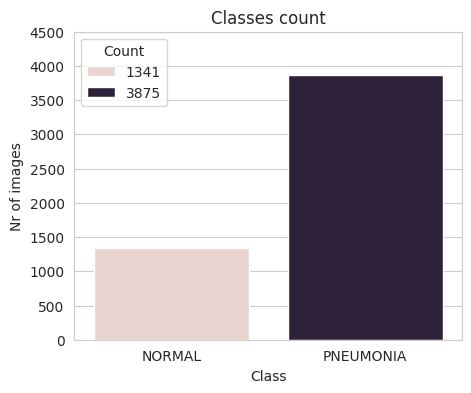

In [10]:
plt.figure(figsize = (5,4))
sns.barplot(data = df, x = 'Class', y = 'Count', hue = 'Count')
plt.title('Classes count')
plt.ylabel('Nr of images')
plt.ylim(0, 4500)


In [11]:
train_data[0][1], train_data[-1][1]


(0, 1)

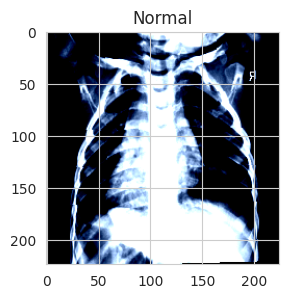

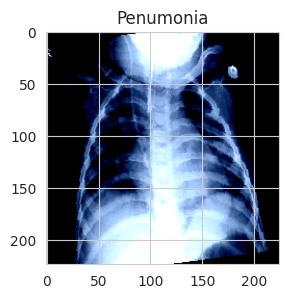

In [12]:
plt.figure(figsize=(3, 5))
plt.imshow(train_data[1][0].permute(1, 2, 0).numpy())
plt.title("Normal")
plt.show()

plt.figure(figsize=(3, 5))
plt.imshow(train_data[-1][0].permute(1, 2, 0).numpy())
plt.title("Penumonia")
plt.show()

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device", device)

Device cuda


In [14]:
class_counts = Counter(train_data.targets)
num_samples = len(train_data.targets)

class_weights = [
    num_samples / (class_counts[i] * len(class_counts))
    for i in class_counts
]

class_weights = torch.FloatTensor(class_weights).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [15]:
model = models.resnet18(pretrained = True)

for params in model.parameters():
  params.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr = 1e-4)

patience = 3
best_val_loss = float('inf')
counter = 0
epochs = 20

for e in range(epochs):

  model.train()
  train_loss = 0

  for data, targets in train_loader:
    data = data.to(device)
    targets = targets.to(device)
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output, targets)
    loss.backward()
    optimizer.step()

    train_loss +=loss.item()

  train_loss/= len(train_loader)

  model.eval()
  val_loss = 0
  with torch.no_grad():
    for data, targets in val_loader:
      data, targets = data.to(device), targets.to(device)
      output = model(data)
      loss = criterion(output, targets)
      val_loss += loss.item()

    val_loss /= len(val_loader)

  print(f"Epoch: {e} | Train_Loss: {train_loss} | Val_Loss: {val_loss} ")

    # Early Stoping
  if val_loss < best_val_loss:
      best_val_loss = val_loss
      counter = 0
      torch.save(model.state_dict(), "best_model.pth")
      print(" Best model saved")

  else:
        counter += 1
        print(f"No improvement {counter} / {patience}")

        if counter >= patience:
          print("Early Stoping Triggered")
  break





/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch: 0 | Train_Loss: 0.13443698775183205 | Val_Loss: 0.1443597823381424 
 Best model saved


In [16]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        output = model(images)
        _, predicted = torch.max(output, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

In [17]:
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 91.99%
Precision: 0.8991
Recall   : 0.9821
F1 Score : 0.9387


<Axes: >

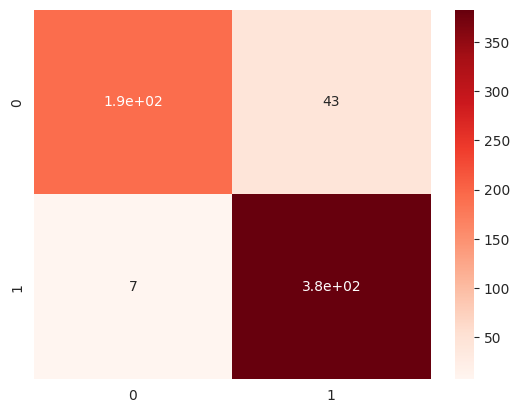

In [18]:
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, cmap='Reds', annot=True)

###The false positives number is noticeably higher then the false negative ones, meaning that the model over predicts pneumonia. This happens probably because the dataset is imbalanced(more pneumonia cases make the model biased towards that) or the image quality on some examples is poor.